In [8]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


import import_ipynb
import nbimporter
from utils import prepareTrainingSet30Sec, standardization, prepareTrainingSet3Sec, metrics,encode_labels,Grafico_Tre_Valori, ConfrontoGrafico_30_e_3 , evaluate_Model # type: ignore



3 secondi


In [10]:
X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()


In [11]:
knn = KNeighborsClassifier(n_neighbors=3)
# Addestriamo il modello
knn.fit(X_train, y_train)

# Prediciamo sul set di test
y_pred = knn.predict(X_test)

before_3sec=accuracy_score(y_test, y_pred)

#metrics(y_test, y_pred)



y_pred_train=knn.predict(X_train)
evaluate_Model(y_test,y_pred,y_train,y_pred_train)

---------STATISTICHE TEST----------
Accuratezza: 0.2548
Precision: 0.2689
Recall: 0.2540
F1-score: 0.2495
F2-score: 0.2497
---------STATISTICHE TRAING----------
Accuratezza: 0.5533
Precision: 0.5950
Recall: 0.5536
F1-score: 0.5449
F2-score: 0.5440

=== Analisi ===
Il modello potrebbe soffrire di OVERFITTING (performance molto migliore sul training set).


In [12]:
X_train, X_test= standardization(X_train, X_test)

# Addestriamo il modello
knn.fit(X_train, y_train)

# Prediciamo sul set di test
y_pred = knn.predict(X_test)

before_3sec_standadization=accuracy_score(y_test, y_pred)
y_pred_train=knn.predict(X_train)
evaluate_Model(y_test,y_pred,y_train,y_pred_train)

---------STATISTICHE TEST----------
Accuratezza: 0.9149
Precision: 0.9151
Recall: 0.9139
F1-score: 0.9141
F2-score: 0.9139
---------STATISTICHE TRAING----------
Accuratezza: 0.9555
Precision: 0.9561
Recall: 0.9556
F1-score: 0.9555
F2-score: 0.9555

=== Analisi ===
Il modello sembra bilanciato e generalizza bene.


In [14]:

X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()

y_train, y_test, label_encoder = encode_labels(y_train, y_test)

X_train, X_test= standardization(X_train, X_test)


# Configurazione del modello KNN
knn = KNeighborsClassifier()

# Griglia degli iperparametri
param_grid = {
    'n_neighbors': [3, 5, 7],
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance']
}


# Grid Search su tutte le metriche
grid_search = GridSearchCV( estimator=knn, param_grid=param_grid, scoring='accuracy', refit='accuracy',  cv=5)

# Esegui la Grid Search
grid_search.fit(X_train, y_train)


#Mostra i migliori parametri trovati
print("Migliori iperparametri trovati:", grid_search.best_params_)

# Valutazione del modello con i migliori parametri
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Calcolo delle metriche
y_pred_train=best_rf.predict(X_train)
evaluate_Model(y_test,y_pred,y_train,y_pred_train)
after_3sec=accuracy_score(y_test, y_pred)
knn3Sec=after_3sec


Migliori iperparametri trovati: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
---------STATISTICHE TEST----------
Accuratezza: 0.9374
Precision: 0.9372
Recall: 0.9370
F1-score: 0.9369
F2-score: 0.9369
---------STATISTICHE TRAING----------
Accuratezza: 0.9992
Precision: 0.9993
Recall: 0.9993
F1-score: 0.9992
F2-score: 0.9992

=== Analisi ===
Il modello sembra bilanciato e generalizza bene.


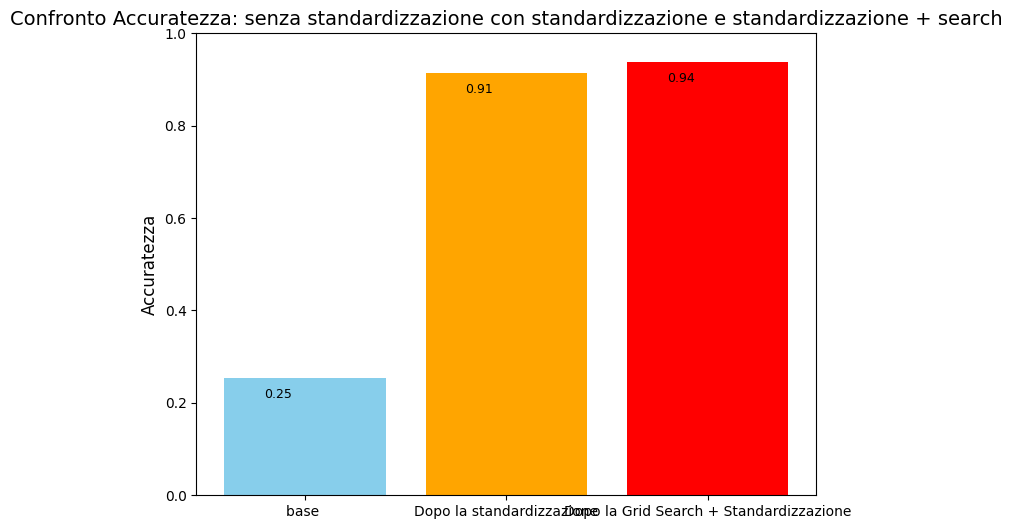

In [15]:
Grafico_Tre_Valori(before_3sec,before_3sec_standadization,after_3sec)